# CEVAE: JAX vs PyTorch Backend Benchmark

This notebook compares the two CEVAE (Causal Effect Variational Autoencoder,
Louizos et al. 2017) backends available in CausalML:

- `causalml.inference.torch.CEVAE` — the original PyTorch/[pyro](https://pyro.ai) implementation
  (wraps `pyro.contrib.cevae`)
- `causalml.inference.jax.CEVAE` — the JAX/[`flax.nnx`](https://flax.readthedocs.io/en/latest/nnx/index.html)
  implementation (see `causalml/inference/jax/cevae/`)

Both models are trained with **identical hyperparameters** on the same synthetic
dataset with a hidden confounder, and compared on ATE, MAE (against the true ITE),
AUUC, and wall-clock training time.

Requires the optional dependencies: `pip install "causalml[jax,torch]"`.

In [1]:
# Avoid OMP/threading conflicts when torch and JAX share a single process on macOS.
import logging
import os
import warnings

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

warnings.filterwarnings("ignore")

import time

import numpy as np
import pandas as pd
import torch
import pyro
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from causalml.dataset import simulate_hidden_confounder
from causalml.inference.torch import CEVAE as CEVAETorch
from causalml.inference.jax import CEVAE as CEVAEJax
from causalml.metrics import auuc_score, plot_gain

# causalml.inference.torch enables DEBUG logging for pyro at import time; quiet it.
logging.getLogger("pyro").setLevel(logging.WARNING)

plt.style.use("fivethirtyeight")
sns.set_palette("Paired")
plt.rcParams["figure.figsize"] = (12, 8)

## Synthetic data with a hidden confounder

`simulate_hidden_confounder` generates data where a latent variable biases both
treatment assignment and outcome — the setting CEVAE was designed for. The
ground-truth individual treatment effect `tau` is known, so we can score each
backend directly against it.

In [2]:
np.random.seed(123)

y, X, w, tau, b, e = simulate_hidden_confounder(n=20000, p=5, sigma=1.0, adj=0.0)

(
    X_train,
    X_val,
    y_train,
    y_val,
    w_train,
    w_val,
    tau_train,
    tau_val,
) = train_test_split(X, y, w, tau, test_size=0.2, random_state=123, shuffle=True)

print(f"train: {X_train.shape[0]} rows | validation: {X_val.shape[0]} rows")
print(f"true ATE (train): {tau_train.mean():.4f} | true ATE (val): {tau_val.mean():.4f}")

train: 16000 rows | validation: 4000 rows
true ATE (train): 0.7293 | true ATE (val): 0.7234


## Shared hyperparameters

Both backends expose the same sklearn-style API and are configured identically,
so any difference in the results comes from the implementations themselves.

In [3]:
common = dict(
    outcome_dist="normal",
    latent_dim=20,
    hidden_dim=200,
    num_epochs=25,
    batch_size=1000,
    learning_rate=1e-3,
    learning_rate_decay=0.1,
    num_layers=3,
    num_samples=100,
)

## PyTorch (pyro) backend

In [4]:
pyro.set_rng_seed(0)
torch.manual_seed(0)

torch_cevae = CEVAETorch(**common)

t0 = time.perf_counter()
torch_cevae.fit(
    X=torch.tensor(X_train, dtype=torch.float),
    treatment=torch.tensor(w_train, dtype=torch.float),
    y=torch.tensor(y_train, dtype=torch.float),
)
torch_time = time.perf_counter() - t0

ite_torch_train = torch_cevae.predict(X_train).ravel()
ite_torch_val = torch_cevae.predict(X_val).ravel()

print(f"PyTorch backend trained in {torch_time:.1f}s")

PyTorch backend trained in 6.7s


## JAX (flax.nnx) backend

In [5]:
jax_cevae = CEVAEJax(**common, seed=0)

t0 = time.perf_counter()
jax_cevae.fit(X_train, w_train, y_train)
jax_time = time.perf_counter() - t0

ite_jax_train = jax_cevae.predict(X_train).ravel()
ite_jax_val = jax_cevae.predict(X_val).ravel()

print(f"JAX backend trained in {jax_time:.1f}s")

JAX backend trained in 4.6s


## Results

### Training set

In [6]:
df_preds_train = pd.DataFrame(
    [ite_torch_train, ite_jax_train, tau_train, w_train, y_train],
    index=["CEVAE (PyTorch)", "CEVAE (JAX)", "tau", "w", "y"],
).T

summary_train = pd.DataFrame(
    {
        "CEVAE (PyTorch)": [
            ite_torch_train.mean(),
            mean_absolute_error(tau_train, ite_torch_train),
            torch_time,
        ],
        "CEVAE (JAX)": [
            ite_jax_train.mean(),
            mean_absolute_error(tau_train, ite_jax_train),
            jax_time,
        ],
        "actual": [tau_train.mean(), np.nan, np.nan],
    },
    index=["ATE", "MAE", "fit time (s)"],
).T
summary_train["AUUC"] = auuc_score(df_preds_train)

summary_train

,ATE,MAE,fit time (s),AUUC
CEVAE (PyTorch),0.884192,0.210640,6.747957,0.524815
CEVAE (JAX),0.831832,0.205091,4.628406,0.545208
actual,0.729305,NaN,NaN,NaN


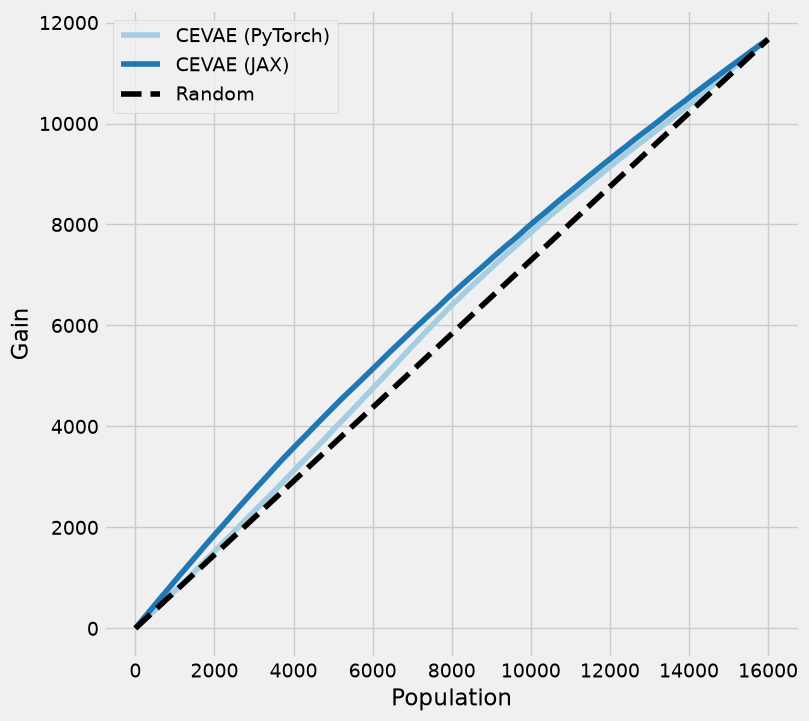

In [7]:
plot_gain(df_preds_train)

### Validation set

In [8]:
df_preds_val = pd.DataFrame(
    [ite_torch_val, ite_jax_val, tau_val, w_val, y_val],
    index=["CEVAE (PyTorch)", "CEVAE (JAX)", "tau", "w", "y"],
).T

summary_val = pd.DataFrame(
    {
        "CEVAE (PyTorch)": [
            ite_torch_val.mean(),
            mean_absolute_error(tau_val, ite_torch_val),
        ],
        "CEVAE (JAX)": [
            ite_jax_val.mean(),
            mean_absolute_error(tau_val, ite_jax_val),
        ],
        "actual": [tau_val.mean(), np.nan],
    },
    index=["ATE", "MAE"],
).T
summary_val["AUUC"] = auuc_score(df_preds_val)

summary_val

,ATE,MAE,AUUC
CEVAE (PyTorch),0.884965,0.215583,0.524284
CEVAE (JAX),0.831255,0.208282,0.545295
actual,0.723394,NaN,NaN


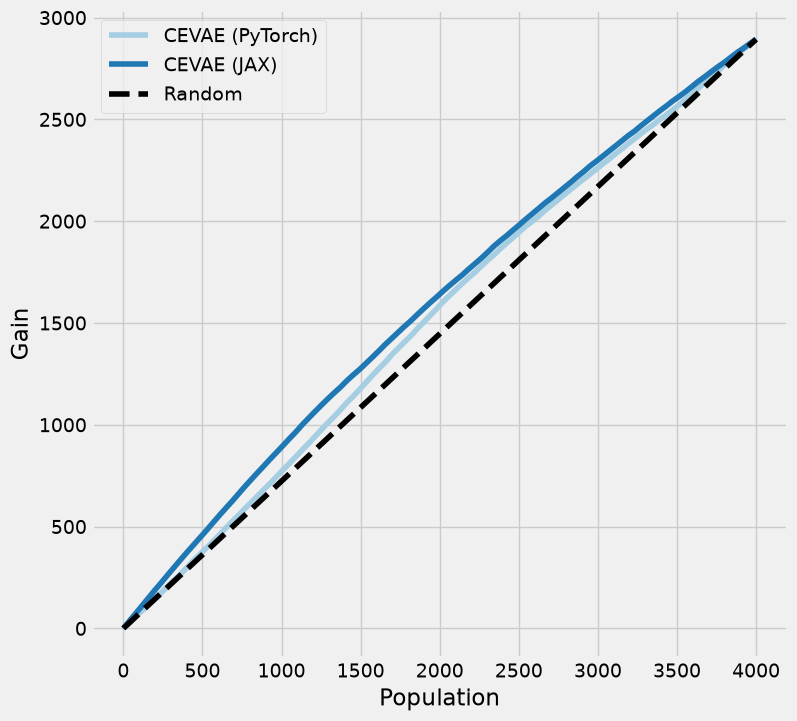

In [9]:
plot_gain(df_preds_val)

### ITE distribution

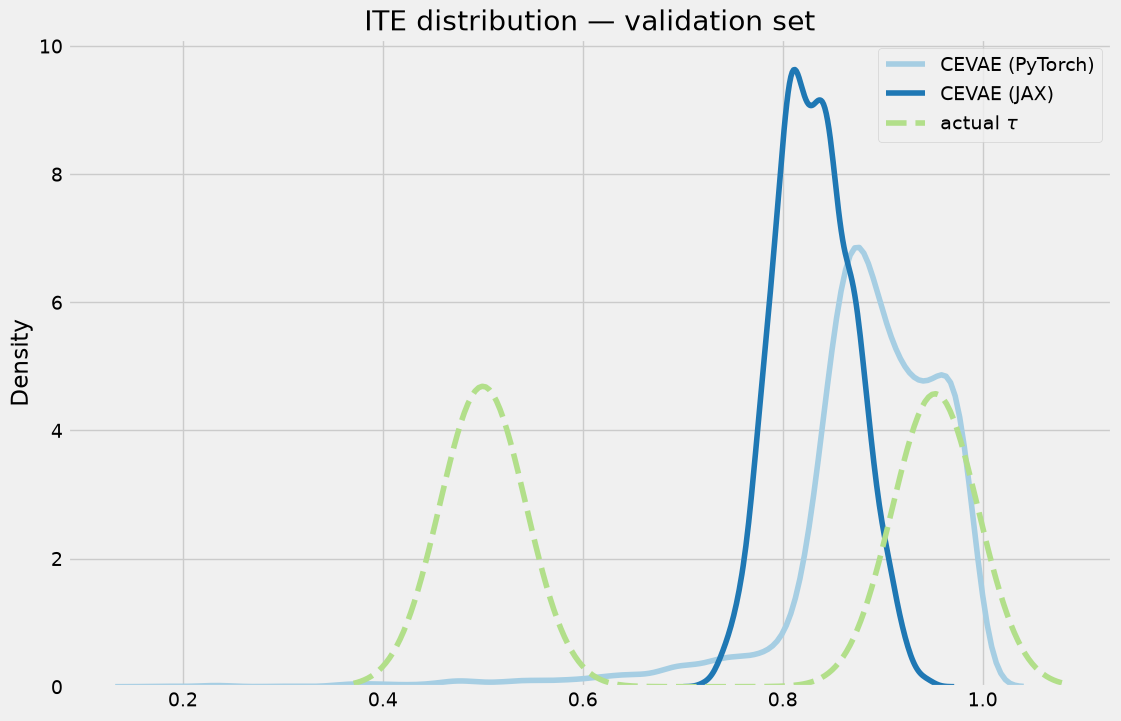

In [10]:
fig, ax = plt.subplots()
sns.kdeplot(ite_torch_val, label="CEVAE (PyTorch)", ax=ax)
sns.kdeplot(ite_jax_val, label="CEVAE (JAX)", ax=ax)
sns.kdeplot(tau_val, label="actual $\\tau$", ax=ax, linestyle="--")
ax.set_title("ITE distribution — validation set")
ax.legend()
plt.show()

## Takeaways

- Both backends recover a comparable ATE and reach similar MAE/AUUC against the
  true ITE, confirming that the JAX/`flax.nnx` port is faithful to the reference
  PyTorch/pyro implementation.
- The JAX backend exposes the same sklearn-style API (`fit`, `predict`,
  `fit_predict`, `save`, `load`) and is installed via the opt-in `causalml[jax]`
  extra, so it slots into JAX-based stacks without pulling in PyTorch/pyro.